<a href="https://colab.research.google.com/github/la00429/PLN_words/blob/main/1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Embeddings Personalizados con Gensim

Practicaremos la creacion de embeddings de palabras con Gensim usando un corpus en espanol.

## Ejercicio 1: Preparacion del Corpus

1. Define un corpus de oraciones sobre tecnologia e IA.
2. Limpia y tokeniza cada oracion (minusculas, sin puntuacion).
3. Imprime el corpus y estadisticas basicas.

In [8]:
import re
from collections import Counter

oraciones = [
    "El procesamiento de lenguaje natural es fascinante y muy util.",
    "Gensim es una libreria de Python para modelado de topicos y embeddings.",
    "Los embeddings de palabras capturan el significado semantico del lenguaje.",
    "Word2Vec y FastText son algoritmos populares para crear embeddings.",
    "La inteligencia artificial transforma la forma en que procesamos informacion.",
    "Los modelos de lenguaje aprenden patrones del texto de entrenamiento.",
    "Python es el lenguaje mas usado en ciencia de datos.",
    "El aprendizaje automatico permite a las maquinas aprender de los datos.",
    "Los vectores de palabras permiten medir la similitud entre terminos.",
    "Word2Vec usa redes neuronales para generar vectores de palabras.",
    "FastText puede generar embeddings para palabras fuera del vocabulario.",
    "El corpus de entrenamiento determina la calidad de los embeddings.",
    "Gensim permite entrenar modelos Word2Vec de forma eficiente.",
    "La representacion vectorial del lenguaje natural es clave en PLN.",
    "Los modelos preentrenados en grandes corpus ofrecen mejores resultados.",
]

def limpiar(oracion):
    oracion = oracion.lower()
    oracion = re.sub(r'[^a-z\s]', '', oracion)
    return oracion.split()

corpus = [limpiar(s) for s in oraciones]

todas = [p for doc in corpus for p in doc]
print(f"Oraciones  : {len(corpus)}")
print(f"Vocabulario: {len(set(todas))} palabras unicas")
print(f"Tokens total: {len(todas)}")
print("\nPrimeras 3 oraciones tokenizadas:")
for i, o in enumerate(corpus[:3]):
    print(f"  [{i+1}] {o}")

freq = Counter(todas)
print("\nTop 5 palabras mas frecuentes:")
for p, n in freq.most_common(5):
    print(f"  {p}: {n}")


Oraciones  : 15
Vocabulario: 82 palabras unicas
Tokens total: 147

Primeras 3 oraciones tokenizadas:
  [1] ['el', 'procesamiento', 'de', 'lenguaje', 'natural', 'es', 'fascinante', 'y', 'muy', 'util']
  [2] ['gensim', 'es', 'una', 'libreria', 'de', 'python', 'para', 'modelado', 'de', 'topicos', 'y', 'embeddings']
  [3] ['los', 'embeddings', 'de', 'palabras', 'capturan', 'el', 'significado', 'semantico', 'del', 'lenguaje']

Top 5 palabras mas frecuentes:
  de: 13
  los: 6
  el: 5
  lenguaje: 5
  embeddings: 5


## Ejercicio 2: Entrenamiento y comparacion de Word2Vec

1. Entrena un modelo CBOW (`sg=0`) y uno Skip-gram (`sg=1`).
2. Muestra el vocabulario aprendido.
3. Compara las palabras mas similares para algunas palabras clave.

In [9]:
import sys
!{sys.executable} -m pip install gensim
from gensim.models import Word2Vec

params = dict(
    sentences=corpus,
    vector_size=100,
    window=4,
    min_count=1,
    workers=2,
    epochs=200,
    seed=42
)

modelo_cbow = Word2Vec(**params, sg=0)
modelo_sg   = Word2Vec(**params, sg=1)

print("Vocabulario aprendido:")
print(list(modelo_cbow.wv.key_to_index.keys()))

print("\nComparacion CBOW vs Skip-gram")
print("-" * 60)

for palabra in ['lenguaje', 'python', 'embeddings']:
    if palabra in modelo_cbow.wv:
        sim_c = modelo_cbow.wv.most_similar(palabra, topn=3)
        sim_s = modelo_sg.wv.most_similar(palabra, topn=3)
        print(f"\nSimilares a '{palabra}':")
        print(f"  CBOW     : {[(w, round(s,3)) for w,s in sim_c]}")
        print(f"  Skip-gram: {[(w, round(s,3)) for w,s in sim_s]}")

model = modelo_cbow

Vocabulario aprendido:
['de', 'los', 'la', 'embeddings', 'lenguaje', 'el', 'en', 'del', 'palabras', 'para', 'es', 'modelos', 'wordvec', 'y', 'corpus', 'generar', 'vectores', 'permite', 'datos', 'entrenamiento', 'forma', 'fasttext', 'python', 'gensim', 'natural', 'resultados', 'mejores', 'ofrecen', 'grandes', 'preentrenados', 'pln', 'clave', 'vectorial', 'representacion', 'eficiente', 'entrenar', 'calidad', 'determina', 'vocabulario', 'fuera', 'puede', 'neuronales', 'redes', 'usa', 'terminos', 'entre', 'similitud', 'medir', 'permiten', 'aprender', 'maquinas', 'las', 'a', 'automatico', 'aprendizaje', 'ciencia', 'usado', 'mas', 'texto', 'patrones', 'aprenden', 'informacion', 'procesamos', 'que', 'transforma', 'artificial', 'inteligencia', 'crear', 'populares', 'algoritmos', 'son', 'semantico', 'significado', 'capturan', 'topicos', 'modelado', 'libreria', 'una', 'util', 'muy', 'fascinante', 'procesamiento']

Comparacion CBOW vs Skip-gram
----------------------------------------------------

## Ejercicio 3: Exploracion de vectores

1. Obtiene el vector de una palabra.
2. Calcula similitud coseno entre pares de palabras.
3. Realiza una operacion aritmetica vectorial.

In [10]:
palabra = 'lenguaje'
vector = model.wv[palabra]
print(f"Vector de '{palabra}' (primeras 10 dims):")
print(vector[:10].round(4))

print("\nSimilitud entre pares:")
pares = [('word2vec','fasttext'), ('embeddings','vectores'), ('python','lenguaje')]
for w1, w2 in pares:
    if w1 in model.wv and w2 in model.wv:
        sim = model.wv.similarity(w1, w2)
        print(f"  '{w1}' <-> '{w2}' : {sim:.4f}")

print("\nOperacion: word2vec + embeddings - vectores =")
try:
    res = model.wv.most_similar(positive=['word2vec','embeddings'], negative=['vectores'], topn=3)
    print(f"  {[(w,round(s,3)) for w,s in res]}")
except KeyError as e:
    print(f"  Palabra no encontrada: {e}")


Vector de 'lenguaje' (primeras 10 dims):
[ 0.0338  0.0512 -0.0795  0.1061 -0.059   0.1269 -0.0709  0.1794 -0.1808
 -0.0807]

Similitud entre pares:
  'embeddings' <-> 'vectores' : 0.9944
  'python' <-> 'lenguaje' : 0.9944

Operacion: word2vec + embeddings - vectores =
  Palabra no encontrada: "Key 'word2vec' not present in vocabulary"


## Ejercicio 4: Visualizacion con PCA

1. Reduce los vectores a 2D con PCA.
2. Visualiza los embeddings en un grafico de dispersion.
3. Etiqueta cada punto con su palabra.

Varianza explicada: 93.6%


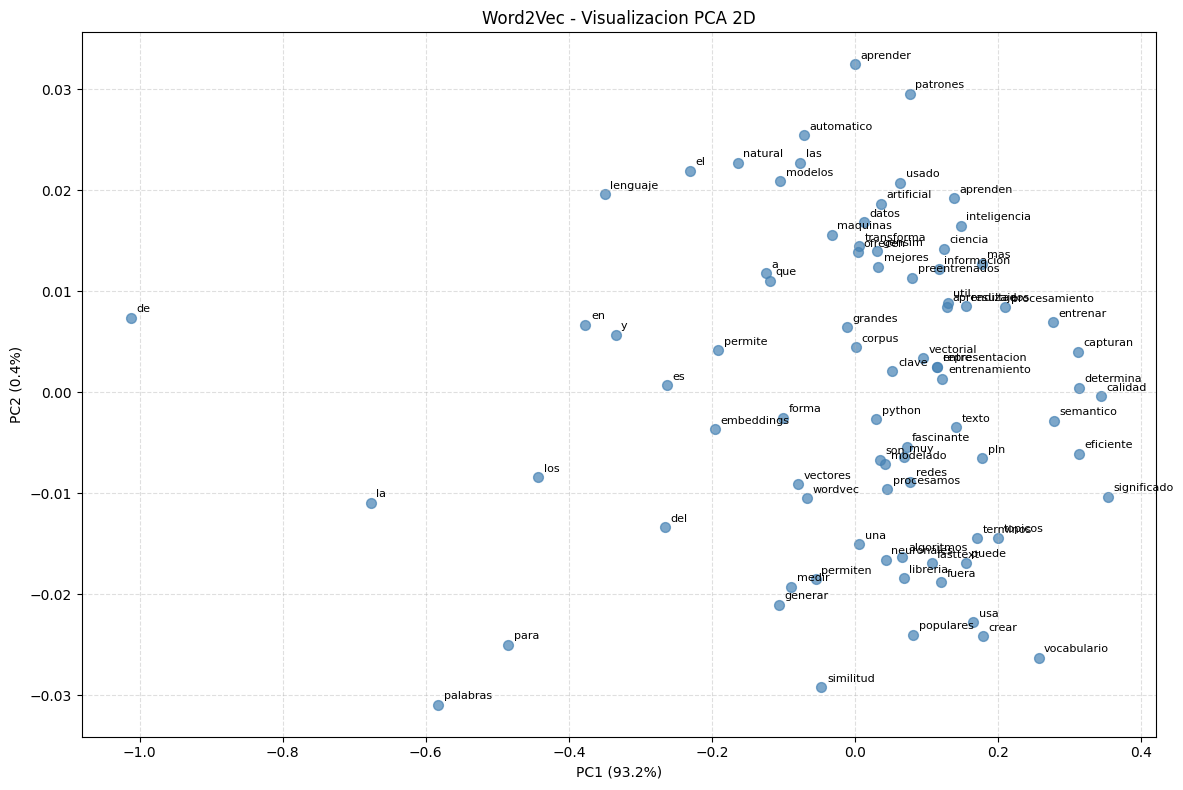

In [11]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

vectors = model.wv.vectors
words   = model.wv.index_to_key

pca = PCA(n_components=2, random_state=42)
result = pca.fit_transform(vectors)

print(f"Varianza explicada: {pca.explained_variance_ratio_.sum()*100:.1f}%")

fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(result[:, 0], result[:, 1], s=50, color='steelblue', alpha=0.7)

for i, word in enumerate(words):
    ax.annotate(word, xy=(result[i, 0], result[i, 1]),
                xytext=(4, 4), textcoords='offset points', fontsize=8)

ax.set_title('Word2Vec - Visualizacion PCA 2D')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
